In [7]:
import pandas as pd

# Load parquet file
train_df = pd.read_parquet("train.parquet")
val_df = pd.read_parquet("val.parquet")

# Show first rows
print(train_df.head())
print(val_df.head())


                                      sequences labels     id
16176  ACCTAGCAATTATGAGTGTACAAGAAGC-TACAATGTCTC      A  16176
71664  GAACTGCCCGACGC--TGGAAGGTGATTA-ACCGCGATAG      B  71664
2370   AGGGCATCAACAATGTCTGAAACTC--TATGTT-TACATA      A   2370
18817  CCGTCCGCACGAATGGAAGGTATCTAGAC-ACTCAGT-CC      B  18817
38435  AAATAAGGTGCACTGCCAATACATCTACTCTCCTGTAGTT      B  38435
                                      sequences labels     id
43507  TTTGTTGAGCTCAATGTCTTTTTCG-ACGGAAGGTAAA-C   both  43507
38379  CCTCTCAGTGTCAATGTCTCCGA-GGAAGTAAGGTCATAA   both  38379
80794  CCAATGTCTGCATCATA-AGGGATCAACTATTCATTCAGT      A  80794
74161  CAATGTCTGGCGGTCATAAAAC-ACAGGAAAGGTCACCTC   both  74161
10711  CTCCAGCTATTACGTGTCGCATATGTAGGCAATGTCTAAT      A  10711


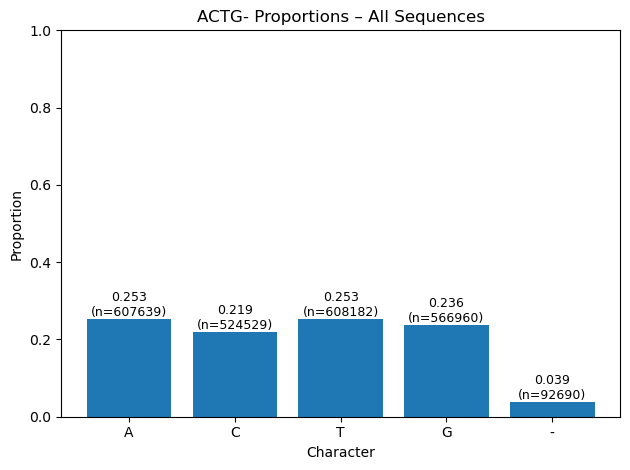

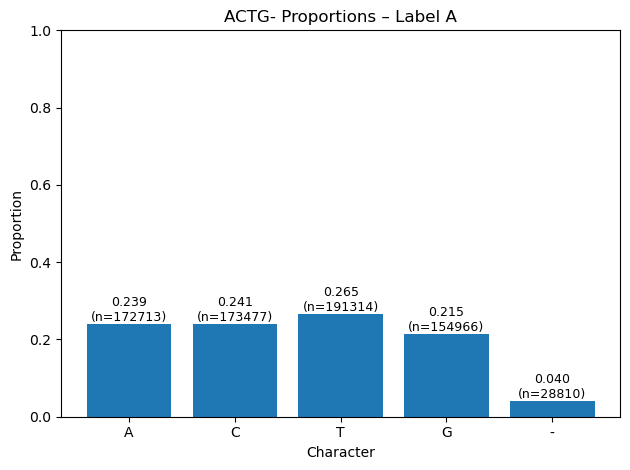

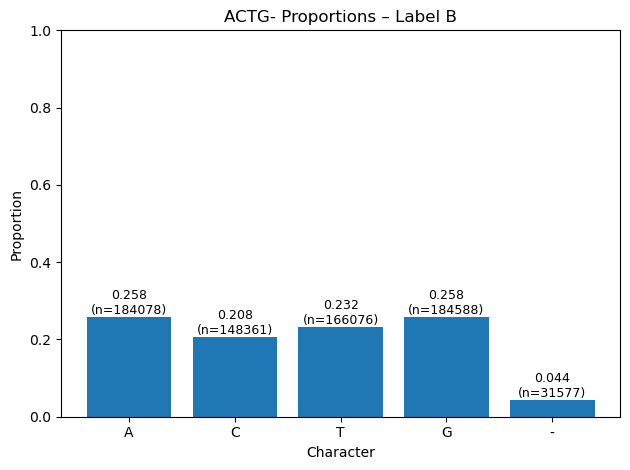

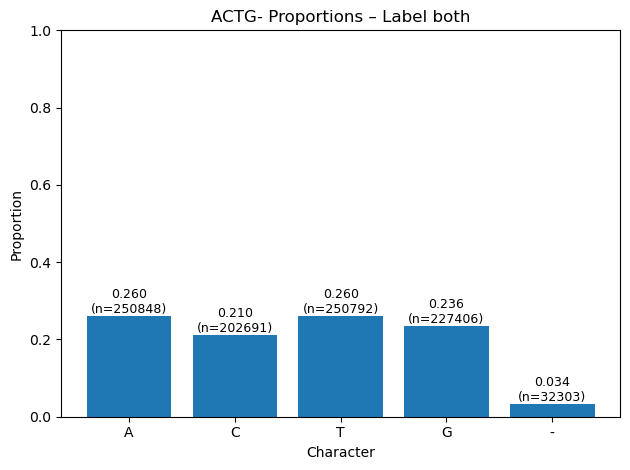

In [12]:
import matplotlib.pyplot as plt
from collections import Counter

def char_stats(seqs):
    chars = []
    for s in seqs:
        chars.extend([c for c in s if c in "ACTG-"])
    counts = Counter(chars)
    total = sum(counts.values())
    props = {k: counts.get(k, 0) / total for k in ["A", "C", "T", "G", "-"]}
    counts = {k: counts.get(k, 0) for k in ["A", "C", "T", "G", "-"]}
    return counts, props

def plot_props(counts, props, title):
    plt.figure()
    bars = plt.bar(props.keys(), props.values())
    plt.xlabel("Character")
    plt.ylabel("Proportion")
    plt.title(title)
    plt.ylim(0, 1)

    # Annotate bars with proportion and count
    for bar, k in zip(bars, props.keys()):
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{props[k]:.3f}\n(n={counts[k]})",
            ha="center",
            va="bottom",
            fontsize=9
        )

    plt.tight_layout()
    plt.savefig(f"{title}.png", dpi=300)
    plt.show()

# All sequences
counts, props = char_stats(train_df["sequences"])
plot_props(
    counts,
    props,
    "ACTG- Proportions – All Sequences"
)

# By label
for lbl in ["A", "B", "both"]:
    counts, props = char_stats(
        train_df[train_df["labels"] == lbl]["sequences"]
    )
    plot_props(
        counts,
        props,
        f"ACTG- Proportions – Label {lbl}"
    )



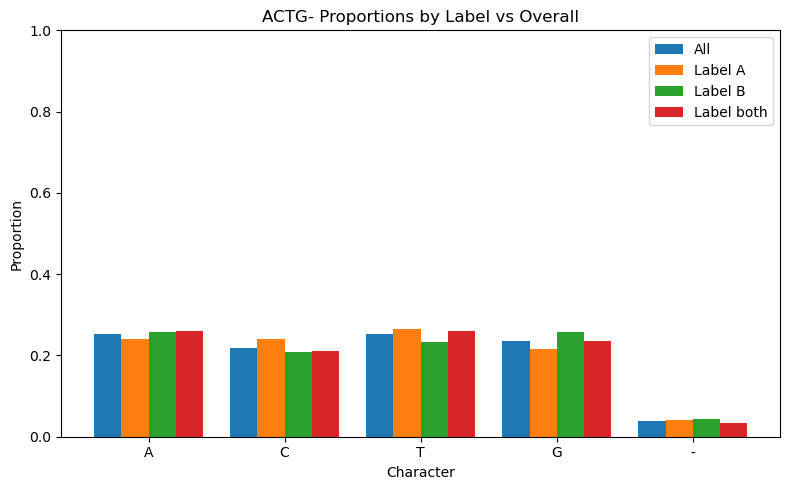

In [16]:
import matplotlib.pyplot as plt
from collections import Counter

def char_proportions(seqs):
    chars = []
    for s in seqs:
        chars.extend([c for c in s if c in "ACTG-"])
    c = Counter(chars)
    total = sum(c.values())
    return {k: c.get(k, 0) / total for k in ["A", "C", "T", "G", "-"]}

# Compute proportions
props_all = char_proportions(train_df["sequences"])
props_A   = char_proportions(train_df[train_df["labels"] == "A"]["sequences"])
props_B   = char_proportions(train_df[train_df["labels"] == "B"]["sequences"])
props_both = char_proportions(train_df[train_df["labels"] == "both"]["sequences"])

labels = ["A", "C", "T", "G", "-"]
x = range(len(labels))
width = 0.2

plt.figure(figsize=(8, 5))

plt.bar([i - 1.5*width for i in x], [props_all[l] for l in labels],
        width, label="All")
plt.bar([i - 0.5*width for i in x], [props_A[l] for l in labels],
        width, label="Label A")
plt.bar([i + 0.5*width for i in x], [props_B[l] for l in labels],
        width, label="Label B")
plt.bar([i + 1.5*width for i in x], [props_both[l] for l in labels],
        width, label="Label both")

plt.xticks(x, labels)
plt.ylabel("Proportion")
plt.xlabel("Character")
plt.title("ACTG- Proportions by Label vs Overall")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()

plt.savefig("ACTG_proportions_grouped.png", dpi=300)
plt.show()


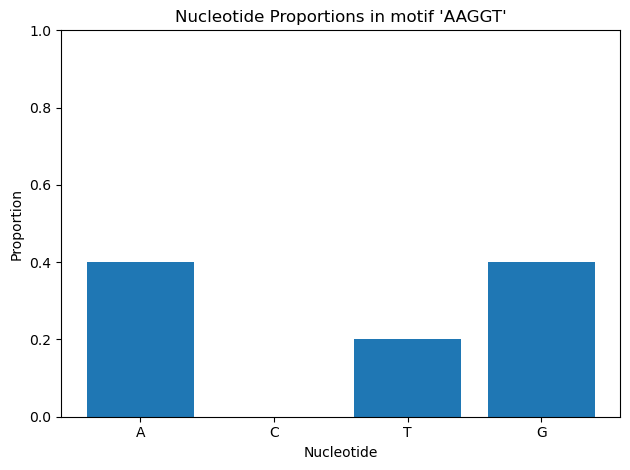

In [15]:
import matplotlib.pyplot as plt
from collections import Counter

# Input string
#seq = "CAATGTCT"
seq = "AAGGT"

# Keep only ACTG
bases = [b for b in seq if b in "ACTG"]

# Proportions
counts = Counter(bases)
total = sum(counts.values())
props = {b: counts.get(b, 0) / total for b in ["A", "C", "T", "G"]}

# ---------- Plot 1: Proportions ----------
plt.figure()
plt.bar(props.keys(), props.values())
plt.ylabel("Proportion")
plt.xlabel("Nucleotide")
plt.title(f"Nucleotide Proportions in motif '{seq}'")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig(f"NucleotideProportionsinmotif{seq}.png", dpi=300)
plt.show()

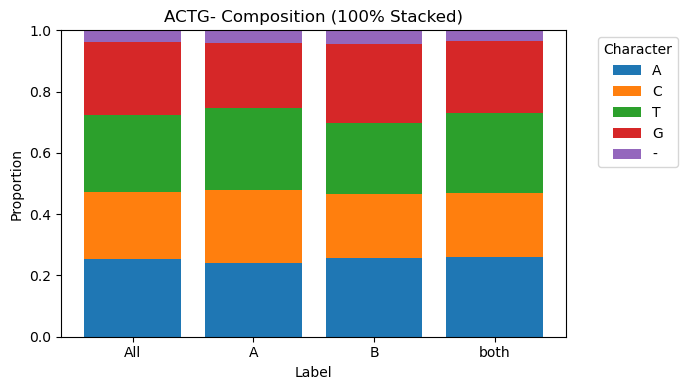

In [17]:
import matplotlib.pyplot as plt
from collections import Counter

def char_proportions(seqs):
    chars = []
    for s in seqs:
        chars.extend([c for c in s if c in "ACTG-"])
    c = Counter(chars)
    total = sum(c.values())
    return {k: c.get(k, 0) / total for k in ["A", "C", "T", "G", "-"]}

labels = ["All", "A", "B", "both"]
data = {
    "All":  char_proportions(train_df["sequences"]),
    "A":    char_proportions(train_df[train_df["labels"] == "A"]["sequences"]),
    "B":    char_proportions(train_df[train_df["labels"] == "B"]["sequences"]),
    "both": char_proportions(train_df[train_df["labels"] == "both"]["sequences"]),
}

chars = ["A", "C", "T", "G", "-"]
x = range(len(labels))

plt.figure(figsize=(7, 4))

bottom = [0] * len(labels)
for c in chars:
    values = [data[l][c] for l in labels]
    plt.bar(x, values, bottom=bottom, label=c)
    bottom = [b + v for b, v in zip(bottom, values)]

plt.xticks(x, labels)
plt.ylabel("Proportion")
plt.xlabel("Label")
plt.title("ACTG- Composition (100% Stacked)")
plt.ylim(0, 1)
plt.legend(title="Character", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

plt.savefig("ACTG_100pct_stacked.png", dpi=300)
plt.show()



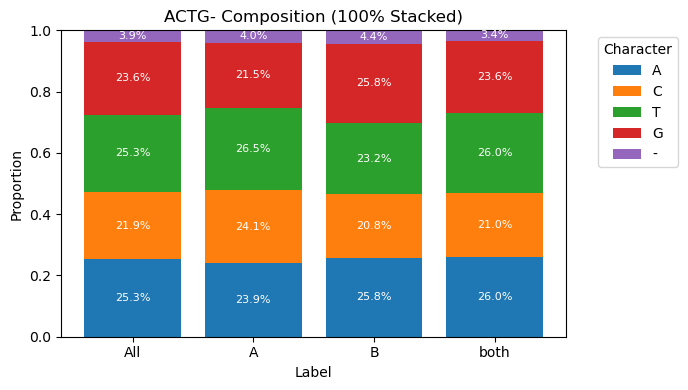

In [18]:
import matplotlib.pyplot as plt
from collections import Counter

def char_proportions(seqs):
    chars = []
    for s in seqs:
        chars.extend([c for c in s if c in "ACTG-"])
    c = Counter(chars)
    total = sum(c.values())
    return {k: c.get(k, 0) / total for k in ["A", "C", "T", "G", "-"]}

labels = ["All", "A", "B", "both"]
data = {
    "All":  char_proportions(train_df["sequences"]),
    "A":    char_proportions(train_df[train_df["labels"] == "A"]["sequences"]),
    "B":    char_proportions(train_df[train_df["labels"] == "B"]["sequences"]),
    "both": char_proportions(train_df[train_df["labels"] == "both"]["sequences"]),
}

chars = ["A", "C", "T", "G", "-"]
x = range(len(labels))

plt.figure(figsize=(7, 4))

bottom = [0] * len(labels)
for c in chars:
    values = [data[l][c] for l in labels]
    bars = plt.bar(x, values, bottom=bottom, label=c)
    
    # Add percentage annotations inside each segment
    for idx, (bar, val, btm) in enumerate(zip(bars, values, bottom)):
        if val > 0.02:  # only label segments >2% to avoid clutter
            plt.text(
                bar.get_x() + bar.get_width()/2,
                btm + val/2,
                f"{val*100:.1f}%",
                ha="center",
                va="center",
                fontsize=8,
                color="white"  # contrast inside bars
            )
    
    bottom = [b + v for b, v in zip(bottom, values)]

plt.xticks(x, labels)
plt.ylabel("Proportion")
plt.xlabel("Label")
plt.title("ACTG- Composition (100% Stacked)")
plt.ylim(0, 1)
plt.legend(title="Character", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

plt.savefig("ACTG_100pct_stacked_with_percent.png", dpi=300)
plt.show()


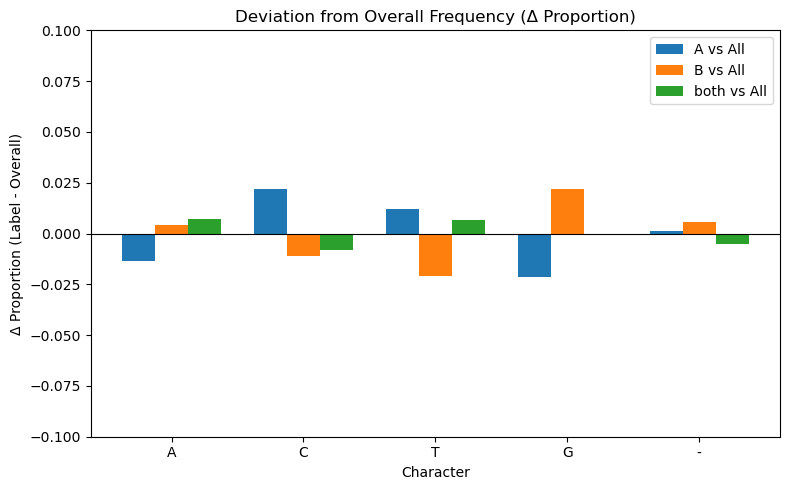

In [24]:
import matplotlib.pyplot as plt
from collections import Counter

def char_proportions(seqs):
    chars = []
    for s in seqs:
        chars.extend([c for c in s if c in "ACTG-"])
    c = Counter(chars)
    total = sum(c.values())
    return {k: c.get(k, 0) / total for k in ["A", "C", "T", "G", "-"]}

# Compute proportions
data = {
    "All":  char_proportions(train_df["sequences"]),
    "A":    char_proportions(train_df[train_df["labels"] == "A"]["sequences"]),
    "B":    char_proportions(train_df[train_df["labels"] == "B"]["sequences"]),
    "both": char_proportions(train_df[train_df["labels"] == "both"]["sequences"]),
}

labels = ["A", "B", "both"]
chars = ["A", "C", "T", "G", "-"]
x = range(len(chars))
width = 0.25

plt.figure(figsize=(8, 5))

# Compute delta relative to "All" and plot
for i, lbl in enumerate(labels):
    delta = [data[lbl][c] - data["All"][c] for c in chars]
    plt.bar([xi + i*width - width for xi in x], delta, width, label=f"{lbl} vs All")

# Make y-axis longer (manually)
plt.ylim(-0.10, 0.10)  # extend beyond typical ±0.1 deltas

plt.axhline(0, color='black', linewidth=0.8)
plt.xticks(x, chars)
plt.ylabel("Δ Proportion (Label - Overall)")
plt.xlabel("Character")
plt.title("Deviation from Overall Frequency (Δ Proportion)")
plt.legend()
plt.tight_layout()
plt.savefig("ACTG_delta_vs_all_long_yaxis.png", dpi=300)
plt.show()
